In [1]:
#Using iris data set!
import torch 
import torch.nn as nn
import torch.nn.functional as F

In [2]:
#Creating a model class that inherits nn.Module
class MyModel(nn.Module):
    def __init__(self, input_features=4, h1=8,h2=6, output_features=3):#h1 is hidden layer 1 and h2 is hidden layer 2
        super().__init__() # This instantiates our inhereted class
        self.fc1 = nn.Linear(input_features, h1,) # fc = fully connected, this sets up the transformation, Linear because it's a linear model
        self.fc2 = nn.Linear(h1,h2)
        self.out = nn.Linear(h2,output_features)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        
        return x

In [3]:
torch.manual_seed(41) #Picking seed for randomization
# Creating an instance of our model

model = MyModel()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv' # From the raw link
my_df = pd.read_csv(url)
my_df

d:\Coding\Anaconda\Lib\ssl.py:524: UserWarning: Bad certificate in Windows certificate store: not enough data: cadata does not contain a certificate (_ssl.c:3974)
  warnings.warn(f"Bad certificate in Windows certificate store: {exc!s}")


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [6]:
#Changing last column from strings to values useful to the model
my_df.species = my_df.species.replace(['setosa','versicolor','virginica'], [0.0,1.0,2.0])
my_df

C:\Users\korisnik\AppData\Local\Temp\ipykernel_4548\2768365082.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df.species = my_df.species.replace(['setosa','versicolor','virginica'], [0.0,1.0,2.0])


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [7]:
#Train, test, split
X = my_df.drop('species',axis=1) # Drop the labels
y = my_df['species']


In [8]:
type(X.values)

numpy.ndarray

In [9]:
# Converting pandas frame to numpy
domain = torch.from_numpy(X.to_numpy())
label = torch.from_numpy(y.to_numpy())

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size= 0.2, random_state=41)

print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

(120, 4) (30, 4)
(120,) (30,)


In [11]:
X_train = torch.FloatTensor(X_train) # We want float because the input data is floats
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train) # Long for better accuracy
y_test = torch.LongTensor(y_test)

In [12]:
# Set the criteria for measuring the error, set the loss function

loss_function = nn.CrossEntropyLoss()

# Choosing an optimizer and learning rate

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [13]:
#Train model
#Epochs we want to run 
epoch = 100
losses = []

for i in range(epoch):
    # Forward propagation
    y_pred = model.forward(X_train)
    
    # Measuring loss
    loss = loss_function(y_pred,y_train)
    
    losses.append(loss.detach().numpy())
    
    if i % 10 == 0:
        print(f'Epoch: {i}, Loss: {loss}')
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0, Loss: 1.2769443988800049
Epoch: 10, Loss: 1.0679196119308472
Epoch: 20, Loss: 0.9125462770462036
Epoch: 30, Loss: 0.6647297143936157
Epoch: 40, Loss: 0.4385957717895508
Epoch: 50, Loss: 0.2810710370540619
Epoch: 60, Loss: 0.17260345816612244
Epoch: 70, Loss: 0.10984816402196884
Epoch: 80, Loss: 0.07746385037899017
Epoch: 90, Loss: 0.06024698168039322


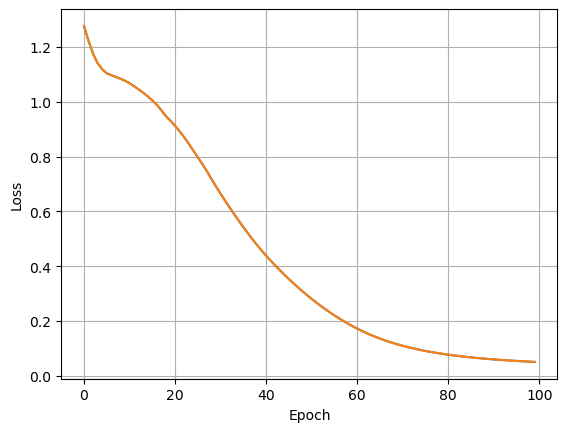

In [17]:
# Graphing the losses
plt.plot(range(epoch), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()